# 08 Extract HTO and Viral Sequences

Extract "HTO expression" for plotting.

In [1]:
import sys
import os
import scanpy as sc
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib

# CUSTOM IMPORTS
# Absolute path to single cell scripts folder
scripts_dir = os.path.abspath("/home/dalbao/AlbaoRunx3Manuscript/single_cell/scripts")

sys.path.append(scripts_dir)

import hto_merge as hto
import vector_features as vf

# Scanpy settings
sc.settings.verbosity = 3
sc.logging.print_header()

# Fonts for illustrator
import matplotlib.font_manager as fm

# Optional: confirm font file is in the right place
font_path = os.path.expanduser("/home/dalbao/.fonts/arial.ttf")
fm.fontManager.addfont(font_path)
arial_font = fm.FontProperties(fname=font_path)

# Editable text in PDF outputs
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['font.family'] = arial_font.get_name()


# Set working directory
os.chdir("/home/dalbao/AlbaoRunx3Manuscript")

2026-08-06 23:19:01.739563: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


scanpy==1.9.6 anndata==0.10.3 umap==0.5.5 numpy==1.24.4 scipy==1.11.3 pandas==2.1.1 scikit-learn==1.1.3 statsmodels==0.14.0 igraph==0.11.3 louvain==0.8.1 pynndescent==0.5.11


In [2]:
# Load adata
rpe = ad.read_h5ad("h5ad/03_25-12-06-01-06_clustering_RPE.h5ad")
mre = ad.read_h5ad("h5ad/03_25-12-08-02-28_clustering_MRE.h5ad")

## Extract HTO

In [3]:
# Extract HTO data
GEM_DIRS = {
    "gem1": "source_data/gem1/outs",
    "gem2": "source_data/gem2/outs",
}

frames = hto.read_cmo_all(GEM_DIRS)

#Pre-flight
hto.detect_barcode_key(rpe, frames)
hto.check_keys(rpe, frames)

hto.detect_barcode_key(mre, frames)
hto.check_keys(mre, frames)

--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading fr

False

In [4]:
# Merge HTO data
hto.merge_hto(rpe, frames, barcode_key="cell_id", batch_key = "gem")
# Merge HTO data
hto.merge_hto(mre, frames, barcode_key="cell_id", batch_key = "gem")

Matched CMO counts for 16314 / 16314 cells.
Matched CMO counts for 28407 / 28407 cells.


AnnData object with n_obs × n_vars = 28407 × 18505
    obs: 'experiment', 'group', 'timepoint', 'infection', 'cell_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'scDblFinder_score', 'scDblFinder_class', 'gem', 'QC', 'n_genes', 'S_score', 'G2M_score', 'phase', 'leiden_r1.5', 'leiden_r1', 'leiden_r0.9', 'leiden_r0.8', 'leiden_r0.7', 'leiden_r0.6', 'leiden_r0.5', 'leiden_r0.4', 'leiden_r0.3', 'leiden_r0.2', 'leiden_r0.1', 'leiden_r1_as_resolved', 'cmo_total', 'cmo_top', 'cmo_top_count', 'cmo_top_frac', 'cmo_second', 'cmo_second_count', 'cmo_margin', 'hto_Base', 'hto_Naive', 'hto_Null', 'hto_WT', 'hto_d5', 'hto_d8', 'hto_dAD', 'hto_dID', 'hto_dVWRPY', 'cmo_cellranger_call'
    var: 'mt', 'ribo', 'n_cells_by_counts-gem1', 'mean_counts-gem1', 'log1p_mean_counts-gem1', 'pct_dropout_by_

## Extract Viral Features

In [5]:
# Extract HTO data
GEM_DIRS_pmia = {
    "gem1": "source_data/pMIA/gem1/outs",
    "gem2": "source_data/pMIA/gem2/outs"
}
GEM_DIRS_lmpd = {
    "gem1": "source_data/LMPD/gem1/outs",
    "gem2": "source_data/LMPD/gem2/outs"
}

frames_pmia = vf.read_feature_counts_all(GEM_DIRS_pmia, ["MESVphi", "gag", "MycRunx3", "IRES", "mAmetrine", "3LTR"])

frames_lmpd = vf.read_feature_counts_all(GEM_DIRS_lmpd, ["mir30loop", "PGK"])

reading source_data/pMIA/gem1/outs/multi/count/raw_feature_bc_matrix.h5
 (0:00:03)


/opt/conda/lib/python3.11/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


source_data/pMIA/gem1/outs: 2639156 barcodes, features ['MESVphi', 'gag', 'MycRunx3', 'IRES', 'mAmetrine', '3LTR']
  cells with nonzero signal: {'MESVphi': 1631, 'gag': 1760, 'MycRunx3': 102, 'IRES': 768, 'mAmetrine': 6291, '3LTR': 31013}
reading source_data/pMIA/gem2/outs/multi/count/raw_feature_bc_matrix.h5
 (0:00:03)


/opt/conda/lib/python3.11/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


source_data/pMIA/gem2/outs: 2703609 barcodes, features ['MESVphi', 'gag', 'MycRunx3', 'IRES', 'mAmetrine', '3LTR']
  cells with nonzero signal: {'MESVphi': 1651, 'gag': 1722, 'MycRunx3': 123, 'IRES': 796, 'mAmetrine': 6379, '3LTR': 30730}
reading source_data/LMPD/gem1/outs/multi/count/raw_feature_bc_matrix.h5
 (0:00:03)


/opt/conda/lib/python3.11/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


source_data/LMPD/gem1/outs: 2639156 barcodes, features ['mir30loop', 'PGK']
  cells with nonzero signal: {'mir30loop': 350, 'PGK': 173}
reading source_data/LMPD/gem2/outs/multi/count/raw_feature_bc_matrix.h5
 (0:00:03)


/opt/conda/lib/python3.11/site-packages/anndata/_core/anndata.py:1899: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


source_data/LMPD/gem2/outs: 2703609 barcodes, features ['mir30loop', 'PGK']
  cells with nonzero signal: {'mir30loop': 424, 'PGK': 161}


In [6]:
vf.append_to_raw(rpe, frames_pmia, ["MESVphi", "gag", "MycRunx3", "IRES", "mAmetrine", "3LTR"], barcode_key="cell_id", batch_key = "gem")
vf.append_to_raw(rpe, frames_lmpd, ["mir30loop", "PGK"], barcode_key="cell_id", batch_key = "gem")

vf.append_to_raw(mre, frames_pmia, ["MESVphi", "gag", "MycRunx3", "IRES", "mAmetrine", "3LTR"], barcode_key="cell_id", batch_key = "gem")
vf.append_to_raw(mre, frames_lmpd, ["mir30loop", "PGK"], barcode_key="cell_id", batch_key = "gem")

Matched 16314 / 16314 cells to the re-aligned run.
Library size from adata.obs['total_counts'].
.raw: 18505 -> 18511 features (values='lognorm')
Matched 16314 / 16314 cells to the re-aligned run.
Library size from adata.obs['total_counts'].
.raw: 18511 -> 18513 features (values='lognorm')
Matched 28407 / 28407 cells to the re-aligned run.
Library size from adata.obs['total_counts'].
.raw: 18505 -> 18511 features (values='lognorm')
Matched 28407 / 28407 cells to the re-aligned run.
Library size from adata.obs['total_counts'].
.raw: 18511 -> 18513 features (values='lognorm')


AnnData object with n_obs × n_vars = 28407 × 18505
    obs: 'experiment', 'group', 'timepoint', 'infection', 'cell_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'doublet_score', 'predicted_doublet', 'scDblFinder_score', 'scDblFinder_class', 'gem', 'QC', 'n_genes', 'S_score', 'G2M_score', 'phase', 'leiden_r1.5', 'leiden_r1', 'leiden_r0.9', 'leiden_r0.8', 'leiden_r0.7', 'leiden_r0.6', 'leiden_r0.5', 'leiden_r0.4', 'leiden_r0.3', 'leiden_r0.2', 'leiden_r0.1', 'leiden_r1_as_resolved', 'cmo_total', 'cmo_top', 'cmo_top_count', 'cmo_top_frac', 'cmo_second', 'cmo_second_count', 'cmo_margin', 'hto_Base', 'hto_Naive', 'hto_Null', 'hto_WT', 'hto_d5', 'hto_d8', 'hto_dAD', 'hto_dID', 'hto_dVWRPY', 'cmo_cellranger_call', 'MESVphi_counts', 'gag_counts', 'MycRunx3_counts', 'IRES_counts', 'mAmetrine_counts', '3LTR_counts', 'mir30loo

## Plot

In [7]:
# Prepend "RPE" to leiden_r1 column and place into new RPE columns
rpe.obs["RPE"] = "RPE" + rpe.obs["leiden_r1"].astype(str)
# Make a copy of rpe containing only leiden_r1 in 0 1 2 3 4 5 6 7 8 9 10
rpe_subset = rpe[rpe.obs["leiden_r1"].isin(["0", "1", "2", "3", "4", "5", "6", "7", "8", "10"]), :]

# Order RPE clusters by factorization
rpe_subset.obs["RPE"] = pd.Categorical(rpe_subset.obs["RPE"], categories=["RPE2", "RPE4", "RPE0", "RPE1", "RPE3", "RPE5", "RPE7", "RPE6", "RPE10", "RPE8"])

/tmp/ipykernel_179448/790246766.py:7: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  rpe_subset.obs["RPE"] = pd.Categorical(rpe_subset.obs["RPE"], categories=["RPE2", "RPE4", "RPE0", "RPE1", "RPE3", "RPE5", "RPE7", "RPE6", "RPE10", "RPE8"])


In [8]:
# I have a CSV file called WangGeneSets.csv which contains gene sets.
# This is a headless CSV with three columns, the first 2 are relevant: gs_name and gene_symbol.
# it contains two gs_names, WangD8Runx3Promoted and WangD5Runx3Promoted
# I want to score RPE_subset using these two gene sets and add the scores to the adata.obs
# Call it Runx3D5Sig and Runx3D8Sig

# Load gene sets from CSV
gene_sets = pd.read_csv("source_data/WangGeneSets.csv", header=None)
# It is a headless CSV, so we need to specify the column names
gene_sets.columns = ["gs_name", "gene_symbol", "ENSEMBL"]

# Rename gs_names to match the desired score names
gene_sets["gs_name"] = gene_sets["gs_name"].replace({
    "WangD5Runx3Promoted": "Runx3D5Sig",
    "WangD8Runx3Promoted": "Runx3D8Sig",
    "Albao_Runx3OE": "Runx3OE_Up",
    "Albao_Runx3OE_Down": "Runx3OE_Down",
    "Albao_Runx3KD": "shRunx3_Up",
    "Albao_Runx3KD_Down": "shRunx3_Down"
})

# Create a dictionary of gene sets
gene_set_dict = gene_sets.groupby("gs_name")["gene_symbol"].apply(list).to_dict()

# Score RPE_subset using the gene sets
for gs_name, genes in gene_set_dict.items():
    # Check if genes are in the adata.var_names
    genes_in_data = [g for g in genes if g in rpe_subset.var_names]
    # Score the gene set
    sc.tl.score_genes(rpe_subset, gene_list=genes_in_data, score_name=gs_name)

computing score 'Runx3D5Sig'
    finished: added
    'Runx3D5Sig', score of gene set (adata.obs).
    1194 total control genes are used. (0:00:00)
computing score 'Runx3D8Sig'
    finished: added
    'Runx3D8Sig', score of gene set (adata.obs).
    1197 total control genes are used. (0:00:00)
computing score 'Runx3OE_Down'
    finished: added
    'Runx3OE_Down', score of gene set (adata.obs).
    593 total control genes are used. (0:00:00)
computing score 'Runx3OE_Up'
    finished: added
    'Runx3OE_Up', score of gene set (adata.obs).
    691 total control genes are used. (0:00:00)
computing score 'shRunx3_Down'
    finished: added
    'shRunx3_Down', score of gene set (adata.obs).
    639 total control genes are used. (0:00:00)
computing score 'shRunx3_Up'
    finished: added
    'shRunx3_Up', score of gene set (adata.obs).
    647 total control genes are used. (0:00:00)


/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


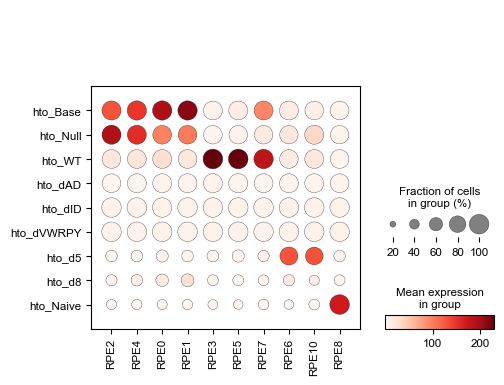

/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


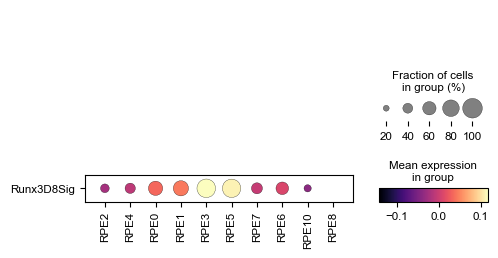

/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


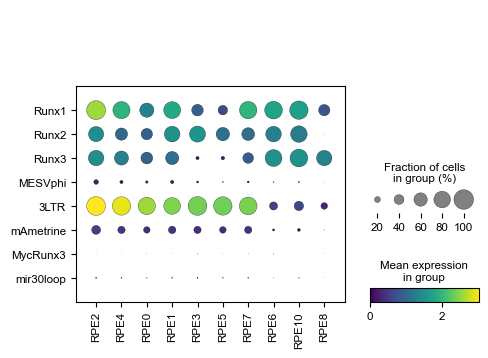

In [9]:
hto_keys = ["hto_Base", "hto_Null", "hto_WT", "hto_dAD", "hto_dID", "hto_dVWRPY", "hto_d5", "hto_d8", "hto_Naive"]
sigs = ["Runx3D8Sig"]
genes = ["Runx1", "Runx2", "Runx3", "MESVphi", "3LTR", "mAmetrine", "MycRunx3", "mir30loop"]

sc.pl.dotplot(rpe_subset, hto_keys, groupby="RPE", swap_axes=True, use_raw=True, save="rpe_dotplot_hto.pdf")
sc.pl.dotplot(rpe_subset, sigs, groupby="RPE", swap_axes=True, use_raw=True, cmap = "magma", save="rpe_dotplot_sig.pdf")
sc.pl.dotplot(rpe_subset, genes, groupby="RPE", swap_axes=True, use_raw=True, cmap = "viridis", save="rpe_dotplot_genes.pdf")

In [10]:
# Prepend "MRE" to leiden_r1 column and place into new MRE columns
mre.obs["MRE"] = "MRE" + mre.obs["leiden_r1"].astype(str)
# Make a copy of rpe containing only leiden_r1 in 0 1 2 3 4 5 6 7 8 9 10
mre_subset = mre[mre.obs["leiden_r1"].isin(["0", "1", "2", "3", "4", "5", "6", "7", "8", "10"]), :]
# Order MRE clusters by factorization
mre_subset.obs["MRE"] = pd.Categorical(mre_subset.obs["MRE"], categories=["MRE0", "MRE1", "MRE6", "MRE7", "MRE3", "MRE2", "MRE5", "MRE4", "MRE8", "MRE10"])


# Score RPE_subset using the gene sets
for gs_name, genes in gene_set_dict.items():
    # Check if genes are in the adata.var_names
    genes_in_data = [g for g in genes if g in rpe_subset.var_names]
    # Score the gene set
    sc.tl.score_genes(mre_subset, gene_list=genes_in_data, score_name=gs_name)

/tmp/ipykernel_179448/1615712559.py:6: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  mre_subset.obs["MRE"] = pd.Categorical(mre_subset.obs["MRE"], categories=["MRE0", "MRE1", "MRE6", "MRE7", "MRE3", "MRE2", "MRE5", "MRE4", "MRE8", "MRE10"])


computing score 'Runx3D5Sig'
    finished: added
    'Runx3D5Sig', score of gene set (adata.obs).
    1046 total control genes are used. (0:00:00)
computing score 'Runx3D8Sig'
    finished: added
    'Runx3D8Sig', score of gene set (adata.obs).
    1195 total control genes are used. (0:00:00)
computing score 'Runx3OE_Down'
    finished: added
    'Runx3OE_Down', score of gene set (adata.obs).
    641 total control genes are used. (0:00:00)
computing score 'Runx3OE_Up'
    finished: added
    'Runx3OE_Up', score of gene set (adata.obs).
    688 total control genes are used. (0:00:00)
computing score 'shRunx3_Down'
    finished: added
    'shRunx3_Down', score of gene set (adata.obs).
    594 total control genes are used. (0:00:00)
computing score 'shRunx3_Up'
    finished: added
    'shRunx3_Up', score of gene set (adata.obs).
    648 total control genes are used. (0:00:00)


/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


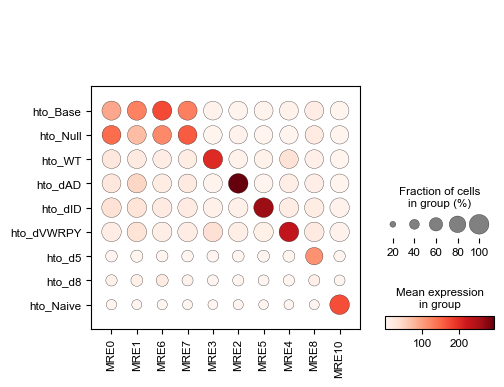

/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


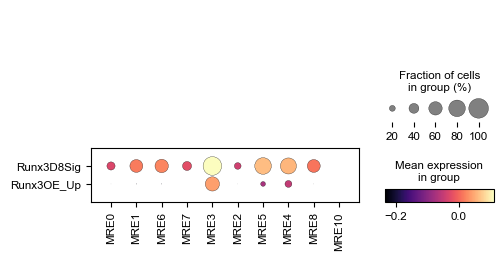

/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


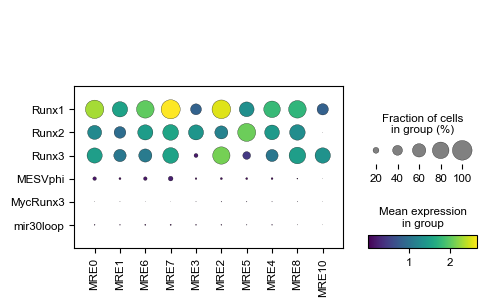

In [11]:
hto_keys = ["hto_Base", "hto_Null", "hto_WT", "hto_dAD", "hto_dID", "hto_dVWRPY", "hto_d5", "hto_d8", "hto_Naive"]
sigs = ["Runx3D8Sig", "Runx3OE_Up"]
genes = ["Runx1", "Runx2", "Runx3", "MESVphi", "MycRunx3", "mir30loop"]

sc.pl.dotplot(mre_subset, hto_keys, groupby="MRE", swap_axes=True, use_raw=True, save="mre_dotplot_hto.pdf")
sc.pl.dotplot(mre_subset, sigs, groupby="MRE", swap_axes=True, use_raw=True, cmap = "magma", save="mre_dotplot_sig.pdf")
sc.pl.dotplot(mre_subset, genes, groupby="MRE", swap_axes=True, use_raw=True, cmap = "viridis", save="mre_dotplot_genes.pdf")

computing score 'Runx3D5Sig'


/opt/conda/lib/python3.11/site-packages/scanpy/tools/_score_genes.py:175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(


    finished: added
    'Runx3D5Sig', score of gene set (adata.obs).
    1190 total control genes are used. (0:00:01)
computing score 'Runx3D8Sig'
    finished: added
    'Runx3D8Sig', score of gene set (adata.obs).
    1146 total control genes are used. (0:00:00)
computing score 'Runx3OE_Down'
    finished: added
    'Runx3OE_Down', score of gene set (adata.obs).
    638 total control genes are used. (0:00:00)
computing score 'Runx3OE_Up'
    finished: added
    'Runx3OE_Up', score of gene set (adata.obs).
    640 total control genes are used. (0:00:00)
computing score 'shRunx3_Down'
    finished: added
    'shRunx3_Down', score of gene set (adata.obs).
    691 total control genes are used. (0:00:00)
computing score 'shRunx3_Up'
    finished: added
    'shRunx3_Up', score of gene set (adata.obs).
    647 total control genes are used. (0:00:00)


/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


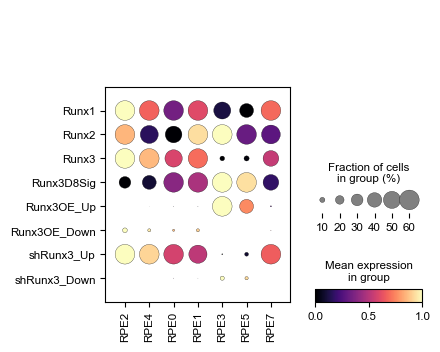

In [12]:
# Prepend "RPE" to leiden_r1 column and place into new RPE columns
rpe.obs["RPE"] = "RPE" + rpe.obs["leiden_r1"].astype(str)
# Make a copy of rpe containing only leiden_r1 in 0 1 2 3 4 5 6 7 8 9 10
rpe_subset2 = rpe[rpe.obs["leiden_r1"].isin(["0", "1", "2", "3", "4", "5", "7"]), :]

# Score RPE_subset using the gene sets
for gs_name, genes in gene_set_dict.items():
    # Check if genes are in the adata.var_names
    genes_in_data = [g for g in genes if g in rpe_subset.var_names]
    # Score the gene set
    sc.tl.score_genes(rpe_subset2, gene_list=genes_in_data, score_name=gs_name, use_raw=True)


# Order RPE clusters by factorization
rpe_subset2.obs["RPE"] = pd.Categorical(rpe_subset2.obs["RPE"], categories=["RPE2", "RPE4", "RPE0", "RPE1", "RPE3", "RPE5", "RPE7"])

sigs = ["Runx1", "Runx2", "Runx3", "Runx3D8Sig", "Runx3OE_Up", "Runx3OE_Down", "shRunx3_Up", "shRunx3_Down"]

sc.pl.dotplot(rpe_subset2, sigs, groupby="RPE", swap_axes=True, use_raw=True, cmap = "magma", standard_scale="var", dot_max = 0.6)

/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


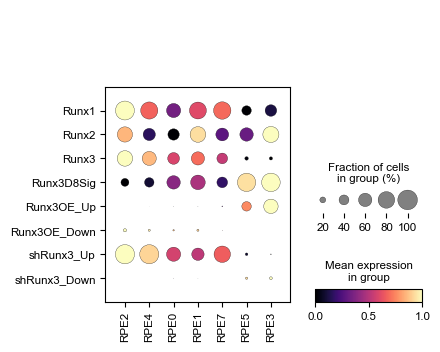

/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


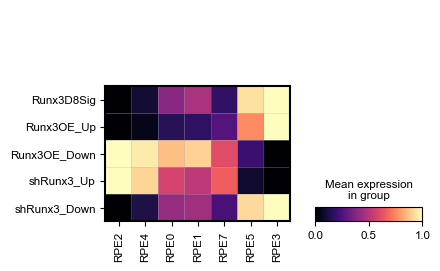

In [19]:
sigs2 = ["Runx3D8Sig", "Runx3OE_Up", "Runx3OE_Down", "shRunx3_Up", "shRunx3_Down"]

rpe_subset2.obs["RPE"] = pd.Categorical(rpe_subset2.obs["RPE"], categories=["RPE2", "RPE4", "RPE0", "RPE1", "RPE7", "RPE5", "RPE3"])

sc.pl.dotplot(rpe_subset2, sigs, groupby="RPE", swap_axes=True, use_raw=True, cmap = "magma", standard_scale="var", dot_max = 1.0)
sc.pl.matrixplot(rpe_subset2, sigs2, groupby="RPE", swap_axes=True, use_raw=True, cmap = "magma", standard_scale="var", save="rpe_sigs_matrixplot.pdf")


In [14]:
wte = ad.read_h5ad("h5ad/03_clustering_WTE.h5ad")


# Prepend "WTE" to leiden_r1 column and place into new WTE columns
wte.obs["WTE"] = "WTE" + wte.obs["leiden_r1"].astype(str)
# Make a copy of wte containing only leiden_r1 in 0 1 2 3 4 5 6 7 8 9 10
wte_subset = wte[wte.obs["leiden_r1"].isin(["0", "3", "2", "6", "1", "4", "5"]), :]
# Order WTE clusters by factorization
wte_subset.obs["WTE"] = pd.Categorical(wte_subset.obs["WTE"], categories=["WTE0", "WTE3", "WTE2", "WTE6", "WTE1", "WTE4", "WTE5"])

# Score RPE_subset using the gene sets
for gs_name, genes in gene_set_dict.items():
    # Check if genes are in the adata.var_names
    genes_in_data = [g for g in genes if g in wte_subset.var_names]
    # Score the gene set
    sc.tl.score_genes(wte_subset, gene_list=genes_in_data, score_name=gs_name, use_raw=True, ctrl_size=len(genes_in_data))

/tmp/ipykernel_179448/513340894.py:9: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  wte_subset.obs["WTE"] = pd.Categorical(wte_subset.obs["WTE"], categories=["WTE0", "WTE3", "WTE2", "WTE6", "WTE1", "WTE4", "WTE5"])


computing score 'Runx3D5Sig'
    finished: added
    'Runx3D5Sig', score of gene set (adata.obs).
    2026 total control genes are used. (0:00:00)
computing score 'Runx3D8Sig'
    finished: added
    'Runx3D8Sig', score of gene set (adata.obs).
    2001 total control genes are used. (0:00:00)
computing score 'Runx3OE_Down'
    finished: added
    'Runx3OE_Down', score of gene set (adata.obs).
    2309 total control genes are used. (0:00:00)
computing score 'Runx3OE_Up'
    finished: added
    'Runx3OE_Up', score of gene set (adata.obs).
    3221 total control genes are used. (0:00:00)
computing score 'shRunx3_Down'
    finished: added
    'shRunx3_Down', score of gene set (adata.obs).
    2609 total control genes are used. (0:00:00)
computing score 'shRunx3_Up'
    finished: added
    'shRunx3_Up', score of gene set (adata.obs).
    896 total control genes are used. (0:00:00)


/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


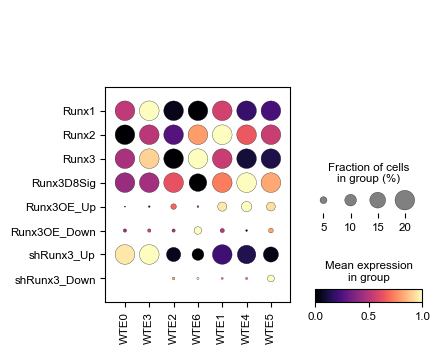

In [15]:
sc.pl.dotplot(wte_subset, sigs, groupby="WTE", swap_axes=True, use_raw=True, cmap = "magma", standard_scale="var", dot_max = 0.2)

In [16]:
wte_subset.obs.to_csv("source_data/wte_subset_obs.csv")

In [17]:
# length of gene lists
gene_set_lengths = {gs_name: len(genes) for gs_name, genes in gene_set_dict.items()}

In [18]:
gene_set_lengths

{'Runx3D5Sig': 120,
 'Runx3D8Sig': 100,
 'Runx3OE_Down': 147,
 'Runx3OE_Up': 155,
 'shRunx3_Down': 147,
 'shRunx3_Up': 60}

/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


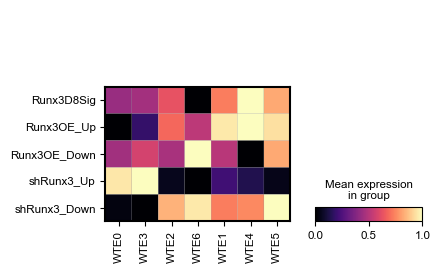

In [20]:
sc.pl.matrixplot(wte_subset, sigs2, groupby="WTE", swap_axes=True, use_raw=True, cmap = "magma", standard_scale="var")

In [21]:
wte_subset.obs["WTE"] = pd.Categorical(wte_subset.obs["WTE"], categories=["WTE3", "WTE0", "WTE6", "WTE2", "WTE1", "WTE5", "WTE4"])


/opt/conda/lib/python3.11/site-packages/scanpy/plotting/_matrixplot.py:143: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  values_df = self.obs_tidy.groupby(level=0).mean()


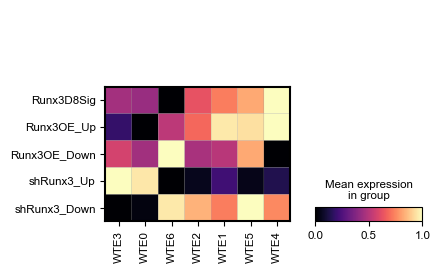

In [23]:
sc.pl.matrixplot(wte_subset, sigs2, groupby="WTE", swap_axes=True, use_raw=True, cmap = "magma", standard_scale="var", save="wte_activity_scale.pdf")